We start by loading the data and defining a time column. Time (in seconds) at the $n^{\text{th}}$ row is defined as $$2n + 5.5 \cdot 3600 \cdot \lfloor \frac{n-1}{900} \rfloor $$.

In [157]:
import pandas as pd
import numpy as np

csv_file_path = 'speeds_and_coordinates_20241016_33_updated.csv'
data = pd.read_csv(csv_file_path)

def calculate_mapped_values(data):
    """
    Adds a new column to the DataFrame that maps the nth row to the formula:
    2 * n + floor((n - 1) / 900) * 5.5 * 3600.

    Args:
        data (pd.DataFrame): The input DataFrame.

    Returns:
        pd.DataFrame: Updated DataFrame with the new 'Mapped Value' column.
    """
    # Calculate row indices starting from 1
    n = data.index + 1  # Row index (n), starting from 1
    # Apply the formula (see iPad)
    data['Time elapsed (in sec)'] = 2 * n + np.floor((n - 1) / 900) * 5.5 * 3600
    data['Time elapsed (in hours)'] = data['Time elapsed (in sec)']/3600
    return data

data = calculate_mapped_values(data)
print(data.iloc[898:904])

     Frame       Speed           X           Y  Changed Pixels  \
898    899    0.623214  379.779221  245.097403              22   
899    900  290.046841  379.760563  245.408451             409   
900    901    0.586822  398.404494  389.228464              15   
901    902    0.491194  398.624060  389.033835              12   
902    903    0.362661  398.384615  389.088462              11   
903    904    0.556377  398.218391  389.160920              25   

     Time elapsed (in sec)  Time elapsed (in hours)  
898                 1798.0                 0.499444  
899                 1800.0                 0.500000  
900                21602.0                 6.000556  
901                21604.0                 6.001111  
902                21606.0                 6.001667  
903                21608.0                 6.002222  


We calculate our own speed column based on the formula $$\text{Speed}_t = \frac{\sqrt{(X_t - X_{t-1})^2+(Y_t - Y_{t-1})^2}}{2}$$
which is shifted and 4 times less than the given speed column.

In [158]:
# Calculate differences in X, Y, and time
data_dx = data['X'].diff()
data_dy = data['Y'].diff()
delta_time = data['Time elapsed (in sec)'].diff()

distance = np.sqrt(data_dx**2 + data_dy**2)
data['dist'] = distance
# Calculate speed as distance divided by time
data['EucSpeed'] = distance / delta_time
data.head()

,Frame,Speed,X,Y,Changed Pixels,Time elapsed (in sec),Time elapsed (in hours),dist,EucSpeed
0,1,0.183495,367.656977,243.308140,4,2.0,0.000556,NaN,NaN
1,2,0.132426,367.637931,243.218391,5,4.0,0.001111,0.091747,0.045874
2,3,0.248908,367.704142,243.218935,5,6.0,0.001667,0.066213,0.033107
3,4,0.286771,367.585366,243.256098,2,8.0,0.002222,0.124454,0.062227
4,5,0.051116,367.716867,243.313253,2,10.0,0.002778,0.143386,0.071693


In [159]:
condition = (data.index) % 900 == 0
data['Changed Pixels'] = data['Changed Pixels'].shift(1)
data.loc[condition, ['EucSpeed', 'Changed Pixels']] = None
data.iloc[897:902]

,Frame,Speed,X,Y,Changed Pixels,Time elapsed (in sec),Time elapsed (in hours),dist,EucSpeed
897,898,0.254468,379.679245,245.176101,11.0,1796.0,0.498889,0.234015,0.117007
898,899,0.623214,379.779221,245.097403,13.0,1798.0,0.499444,0.127234,0.063617
899,900,290.046841,379.760563,245.408451,22.0,1800.0,0.500000,0.311607,0.155804
900,901,0.586822,398.404494,389.228464,NaN,21602.0,6.000556,145.023421,NaN
901,902,0.491194,398.624060,389.033835,15.0,21604.0,6.001111,0.293411,0.146705


A worm sometimes has a behavior where its center of mass is nearly stationary but its head and tail move (see Youtube link). To find when the worm dies, we look at when is there a significant drop in the changed pixels column, which will tell us that the whole body of the worm is stationary. 

Basic Statistics:
              Frame         Speed             X             Y  Changed Pixels  \
count  53995.000000  53995.000000  52217.000000  52217.000000    53935.000000   
mean    5400.000000      2.781865    331.328068    363.107513       68.593529   
std     3117.431633     10.418922    122.065168     78.182759       86.856384   
min        1.000000      0.000000     77.121212     89.605735        0.000000   
25%     2700.000000      0.341868    194.819101    328.593798       15.000000   
50%     5400.000000      1.113021    331.082027    353.953859       47.000000   
75%     8100.000000      2.878539    438.501561    417.545888       92.000000   
max    10799.000000    649.902626    638.035556    666.000000     2585.000000   

       Time elapsed (in sec)  Time elapsed (in hours)          dist  \
count           5.399500e+04             53995.000000  52191.000000   
mean            6.380419e+05               177.233864      1.466731   
std             3.740418e+05           

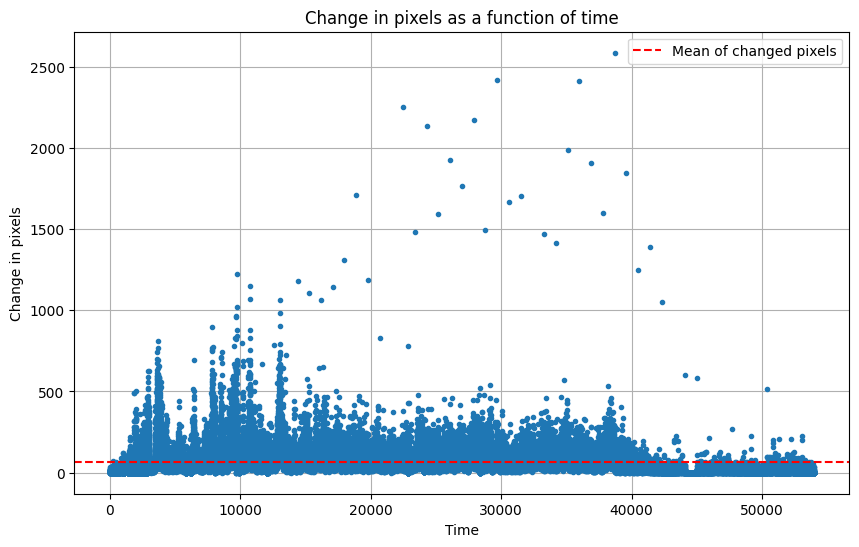

In [160]:
def analyze_and_plot_worm(data):
    """
    Reads a CSV file containing worm trajectory data, performs basic data analysis,
    and plots (X, Y) as a function of time, connecting points in the order listed.
    
    Args:
        csv_file (str): Path to the CSV file.
    """
    
    #data = data.iloc[2000:4000]
    # Quick Data Analysis
    print("Basic Statistics:")
    print(data.describe())
    print("\nMissing Values:")
    print(data.isnull().sum())
    
    #IMPORTANT
    time = range(len(data))
    
    # Plot (X, Y) trajectory
    plt.figure(figsize=(10, 6))
    plt.plot(data.index, data['Changed Pixels'], marker='.', linestyle='')
    plt.title("Change in pixels as a function of time")
    plt.xlabel("Time")
    plt.ylabel("Change in pixels")
    plt.axhline(y=data['Changed Pixels'].mean(), color='red', linestyle='--', label='Mean of changed pixels')
    plt.grid(True)
    plt.legend()
    plt.show()
csv_file_path = 'speeds_and_coordinates_20241016_33_updated.csv'
analyze_and_plot_worm(data)


In [161]:
def find_death_row(data, change_col='Changed Pixels', threshold=5, window=10, persistence=0.9):
    """
    Find the first row where the worm is considered "dead."
    
    Args:
        data (pd.DataFrame): The worm's trajectory data.
        change_col (str): Column indicating changes in pixels.
        threshold (int): Threshold below which the worm is considered inactive.
        window (int): Number of subsequent rows to check for inactivity.
        persistence (float): Fraction of rows in the window that must satisfy the condition.
    
    Returns:
        int: Index of the death row or -1 if no such row is found.
    """
    for i in range(len(data) - window):
        # Check if the current row satisfies the condition
        if data.loc[i, change_col] < threshold:
            # Check the persistence condition in the window
            subsequent = data[change_col].iloc[i:i+window]
            if (subsequent < threshold).sum() >= persistence * window:
                return i
    return -1  # Return -1 if no death row is found

death_row = find_death_row(data, change_col='Changed Pixels', threshold=5, window=500, persistence=0.9)
print(f"Death row: {death_row}")
final_age = data['Time elapsed (in hours)'].iloc[death_row]
print(f"The worm lived: {final_age/24} days.")

Death row: 44034
The worm lived: 12.019328703703705 days.


We now handle NaN values before going further. They include rows where speed is undefined (at resets of recording) or blocks of rows with missing data where the worm moves out of the field of view or if there is an error in tracking. If the block is not very big, we will interpolate the positions of the worm assuming it will have an uniform speed. We will delete the rows otherwise. Additionally, if a recording cut happens in the middle of a block a missing data, the block will be deleted no matter its length.

Basic Statistics:
              Frame         Speed             X             Y  Changed Pixels  \
count  53995.000000  53995.000000  52217.000000  52217.000000    53935.000000   
mean    5400.000000      2.781865    331.328068    363.107513       68.593529   
std     3117.431633     10.418922    122.065168     78.182759       86.856384   
min        1.000000      0.000000     77.121212     89.605735        0.000000   
25%     2700.000000      0.341868    194.819101    328.593798       15.000000   
50%     5400.000000      1.113021    331.082027    353.953859       47.000000   
75%     8100.000000      2.878539    438.501561    417.545888       92.000000   
max    10799.000000    649.902626    638.035556    666.000000     2585.000000   

       Time elapsed (in sec)  Time elapsed (in hours)          dist  \
count           5.399500e+04             53995.000000  52191.000000   
mean            6.380419e+05               177.233864      1.466731   
std             3.740418e+05           

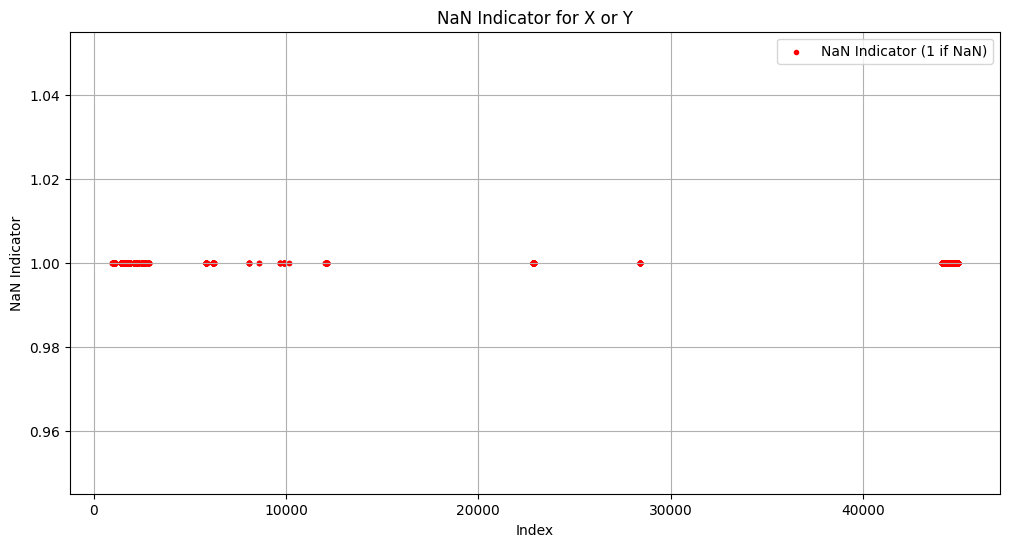

    gap_id  Start Row  End Row  Length  Contains Cut
0        2        979     1020      42         False
1        4       1050     1109      60         False
2        6       1424     1458      35         False
3        8       1497     1558      62         False
4       10       1654     1799     146         False
5       12       1852     1907      56         False
6       14       1911     1920      10         False
7       16       2089     2111      23         False
8       18       2169     2315     147         False
9       20       2482     2557      76         False
10      22       2673     2694      22         False
11      24       2834     2851      18         False
12      26       2892     2898       7         False
13      28       5843     5872      30         False
14      30       6193     6242      50         False
15      32       8061     8068       8         False
16      34       8597     8599       3         False
17      36       9710     9715       6        

In [162]:
import matplotlib.pyplot as plt

print("Basic Statistics:")
print(data.describe())
print("\nMissing Values:")
print(data.isnull().sum())

#Handling NaNs
columns=['X','Y']
nan_rows = data[data[columns].isnull().any(axis=1)]

def plot_nan_indicator(data, columns=['X', 'Y']):
    """
    Plots an indicator where 1 represents NaN values in the specified columns.
    Nothing is plotted for rows without NaN.

    Args:
        data (pd.DataFrame): The input DataFrame.
        columns (list): List of column names to check for NaN values.
    """
    # Create an indicator: 1 if any specified column has NaN, otherwise NaN (no plot for valid values)
    nan_indicator = data[columns].isnull().any(axis=1).astype(int)
    nan_indicator = nan_indicator.replace(0, None)  # Replace 0 with None to exclude from plot

    # Plot the indicator
    plt.figure(figsize=(12, 6))
    plt.scatter(data.index, nan_indicator, label='NaN Indicator (1 if NaN)', color='red', marker='.')
    plt.xlabel('Index')
    plt.ylabel('NaN Indicator')
    plt.title('NaN Indicator for X or Y')
    plt.grid(True)
    plt.legend()
    plt.show()


# Plot NaN indicator for Speed and Acceleration
plot_nan_indicator(data, columns=['X', 'Y'])

data['is_nan'] = data[columns].isnull().any(axis=1)

# Assign unique IDs to consecutive NaN groups
data['gap_id'] = (data['is_nan'] != data['is_nan'].shift()).cumsum() * data['is_nan']

# Group by gap_id to calculate the size of each gap and check for recording cuts
gaps = (
    data[data['is_nan']]
    .groupby('gap_id')
    .apply(lambda group: pd.Series({
        'Start Row': group.index.min(),
        'End Row': group.index.max(),
        'Length': group.index.max() - group.index.min() + 1,
        'Contains Cut': any((group.index) % 900 == 0)  # Check for recording cuts
    }))
    .reset_index()
)
print(gaps)

#gap_length_threshold = 40
#columns=['X', 'Y']
# Process each gap
#for _, gap in gaps.iterrows():
#    gap_id = gap['gap_id']
#    start_row, end_row, length, contains_cut = gap['Start Row'], gap['End Row'], gap['Length'], gap['Contains Cut']

#    if contains_cut or length >= gap_length_threshold:
#        # Delete rows for large gaps or gaps containing a recording cut
#        data = data.drop(index=range(start_row, end_row + 1))
#    else:
        # Interpolate rows for small gaps
#        for column in columns:
#            data.loc[start_row:end_row, column] = np.linspace(
#                data[column].iloc[start_row - 1],  # Value before the gap
#                data[column].iloc[end_row + 1],  # Value after the gap
#                length
#            )

# Drop helper columns
#data = data.drop(columns=['is_nan', 'gap_id'])
#plot_nan_indicator(data, columns=['X', 'Y'])
#print(data.iloc[1320:1330])
data = data.dropna(subset=['X', 'Y', 'EucSpeed'])
data = data.drop(columns=['gap_id', 'is_nan'])
#print(data.isnull().sum())

In [163]:
print(str(gaps.Length.sum()/53995.000000*100)[:5]+'%')

3.292%


In [164]:
data[1300:1380]

,Frame,Speed,X,Y,Changed Pixels,Time elapsed (in sec),Time elapsed (in hours),dist,EucSpeed
1406,1407,0.574321,448.342541,377.613260,18.0,22614.0,6.281667,0.525683,0.262841
1407,1408,0.902253,448.295567,377.896552,22.0,22616.0,6.282222,0.287160,0.143580
1408,1409,0.961000,448.143590,377.471795,18.0,22618.0,6.282778,0.451127,0.225563
1409,1410,2.819738,447.980000,377.020000,45.0,22620.0,6.283333,0.480500,0.240250
1410,1411,0.601660,449.354610,377.333333,31.0,22622.0,6.283889,1.409869,0.704934
...,...,...,...,...,...,...,...,...,...
1580,1581,5.761415,379.326829,253.375610,104.0,22962.0,6.378333,5.874569,2.937285
1581,1582,8.213053,376.446352,253.412017,50.0,22964.0,6.378889,2.880707,1.440354
1582,1583,17.155330,372.352227,253.093117,78.0,22966.0,6.379444,4.106526,2.053263
1583,1584,10.954488,363.838565,254.139013,144.0,22968.0,6.380000,8.577665,4.288832


In [165]:
def add_derived_columns(data, speed_threshold=0.1):
    """
    Adds derived columns to the worm trajectory CSV.

    Args:
        csv_file (str): Path to the input CSV file.
        output_file (str): Path to save the updated CSV file (optional).
        speed_threshold (float): Threshold for stationary flag.

    Returns:
        pd.DataFrame: DataFrame with added columns.
    """
    # Add derived columns
    data['Change in Speed'] = data['EucSpeed'].diff().abs().fillna(0)
    data['Change in Pixels'] = data['Changed Pixels'].diff().fillna(0)
    data['Instantaneous Distance'] = np.sqrt(
        (data['X'].diff() ** 2) + (data['Y'].diff() ** 2)
    ).fillna(0)
    data['Total Distance'] = data['Instantaneous Distance'].cumsum()
    data['Angle'] = np.arctan2(data['Y'].diff(), data['X'].diff()).fillna(0)
    data['Angular Change'] = data['Angle'].diff().abs().fillna(0)
    data['Stationary'] = (data['EucSpeed'] < speed_threshold).astype(int)
    data['Cumulative Stationary Time'] = data['Stationary'].cumsum()

    return data

#output_file = 'updated_worm_file.csv'  # Optional output file
data = add_derived_columns(data)
data.reset_index(inplace = True)
print(data.head())

   index  Frame     Speed           X           Y  Changed Pixels  \
0      1      2  0.132426  367.637931  243.218391             4.0   
1      2      3  0.248908  367.704142  243.218935             5.0   
2      3      4  0.286771  367.585366  243.256098             5.0   
3      4      5  0.051116  367.716867  243.313253             2.0   
4      5      6  0.000000  367.734940  243.295181             2.0   

   Time elapsed (in sec)  Time elapsed (in hours)      dist  EucSpeed  \
0                    4.0                 0.001111  0.091747  0.045874   
1                    6.0                 0.001667  0.066213  0.033107   
2                    8.0                 0.002222  0.124454  0.062227   
3                   10.0                 0.002778  0.143386  0.071693   
4                   12.0                 0.003333  0.025558  0.012779   

   Change in Speed  Change in Pixels  Instantaneous Distance  Total Distance  \
0         0.000000               0.0                0.000000      

In [187]:
THEC = 0.8
w = 15
data['Roaming2'] = data['EucSpeed'].rolling(window=w, center=True).mean()
data['RoamingIndic'] = (data['Roaming2'] > THEC).astype(int)
#data['Roaming Fraction2'] = data['RoamingIndic'].rolling(window=10, center=True, min_periods=1).mean()

In [188]:
data.loc[data['RoamingIndic'] == 1]

,index,Frame,Speed,X,Y,Changed Pixels,Time elapsed (in sec),Time elapsed (in hours),dist,EucSpeed,Change in Speed,Change in Pixels,Instantaneous Distance,Total Distance,Angle,Angular Change,Stationary,Cumulative Stationary Time,Roaming2,RoamingIndic
978,1023,1024,1.276419,415.995169,368.004831,99.0,21848.0,6.068889,5.186584,2.593292,1.470933,-22.0,5.186584,513.552436,1.522979,2.800464,0,171,0.926326,1
979,1024,1025,1.700208,415.928934,368.639594,24.0,21850.0,6.069444,0.638209,0.319105,2.274187,-75.0,0.638209,514.190645,1.674766,0.151788,0,171,0.925102,1
980,1025,1026,1.632994,415.640884,367.839779,24.0,21852.0,6.070000,0.850104,0.425052,0.105947,0.0,0.850104,515.040749,-1.916481,3.591247,0,171,0.952814,1
981,1026,1027,2.268983,415.845679,367.049383,31.0,21854.0,6.070556,0.816497,0.408248,0.016803,7.0,0.816497,515.857246,-1.317267,0.599214,0,171,0.926238,1
982,1027,1028,4.122780,415.687831,365.925926,43.0,21856.0,6.071111,1.134492,0.567246,0.158997,12.0,1.134492,516.991738,-1.710385,0.393117,0,171,0.921483,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43149,44999,1804,0.039859,163.360294,361.036765,1.0,1060200.0,294.500000,0.060366,0.030183,0.079862,-8.0,0.060366,76291.872862,1.801256,3.384450,1,1328,1.696440,1
43150,45001,1806,0.270064,163.242647,361.029412,11.0,1080004.0,300.001111,0.114981,0.057490,0.027308,10.0,0.117877,76291.990739,-3.079174,4.880430,0,1328,1.665810,1
43151,45002,1807,0.623830,163.314770,360.915254,7.0,1080006.0,300.001667,0.135032,0.067516,0.010026,-4.0,0.135032,76292.125771,-1.007333,2.071840,0,1328,1.632109,1
43152,45003,1808,0.572953,163.242788,361.218750,7.0,1080008.0,300.002222,0.311915,0.155958,0.088442,0.0,0.311915,76292.437686,1.803668,2.811002,0,1328,1.610008,1


In [189]:
roaming_frac=data['RoamingIndic'].sum()*2
total_time = (data['Time elapsed (in sec)'].iloc[-1])
print(roaming_frac/total_time)
print(roaming_frac/(final_age*3600))

0.020377843424568443
0.025042610763912294
